In [1]:
import numpy as np
arr = np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201])
arr

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        27,  34,  37, 201])

In [3]:
Q1 = np.percentile(arr,25)
Q3 = np.percentile(arr,75)

In [4]:
IQR = Q3-Q1
IQR

18.0

In [6]:
UF = Q3 + (1.5 * IQR)
LF = Q1 - (1.5 * IQR)
UF,LF

(52.0, -20.0)

In [7]:
l = []
for i in arr:
    if i >=LF and i <=UF:
        l.append(i)

arr2 = np.array(l)

In [8]:
arr2

array([ 2,  3,  4,  6,  7,  8,  9, 12, 13, 16, 17, 23, 25, 27, 34, 37])

<Axes: >

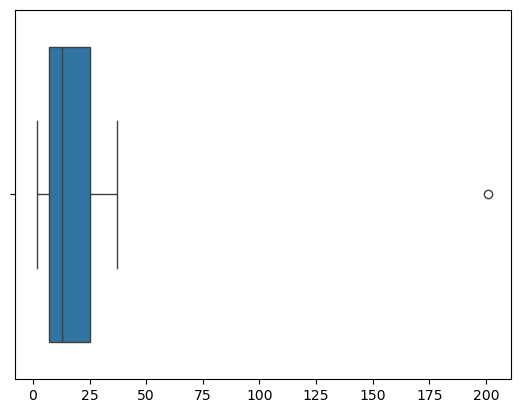

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=arr)

<Axes: >

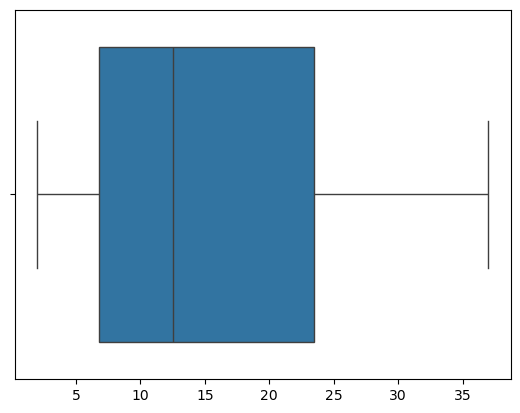

In [14]:
sns.boxplot(x = arr2)

In [15]:
import numpy as np
from scipy.stats import norm


In [21]:
sample = [ 172 ,174,168,169,171,173,175,170,169,172]
population_mean = 170
population_std = 3
samp_mean = np.mean(sample)
n= len(sample)


In [22]:
samp_mean

171.3

In [23]:
z_score = (samp_mean - population_mean)/ (population_std/(np.sqrt(n)))

z_score


1.3703203194063098

In [28]:
p_value = 2 * (1 - norm.cdf(abs(z_score)))
p_value

0.17058693287143756

In [29]:
alpha = 0.05
if p_value < alpha :
    print("I will reject the null hyothesis")
else:
    print ("I will accept the null hypothesis")

I will accept the null hypothesis


t-test

In [45]:
import numpy as np
from scipy import stats

In [46]:
sample = [ 172 ,174,168,169,171,173,175,170,169,172]
population_mean = 170
population_std = 3
samp_mean = np.mean(sample)
n= len(sample)
sample_std = np.std(sample,ddof = 1)


In [47]:
t_stats = (samp_mean - population_mean)/(sample_std/np.sqrt(n))
t_stats

1.7782469350914734

In [49]:
p_value = 2 * (1 - stats.t.cdf(abs(t_stats),df = n-1))
p_value

0.10907771593031335

In [50]:
alpha = 0.05
if p_value < alpha:
    print("reject the null hypothesis")
else:
    print("accept the null hypothesis")

accept the null hypothesis


In [51]:
import numpy as np
from scipy import stats 

In [53]:
group_A = [85,88,90,92,87,85,89,91,86,88]
group_B = [82,84,80,83,81,79,78,85,84,83]


In [57]:
t_stats , p_value = stats.ttest_ind(group_A , group_B ,equal_var = False)
t_stats

5.829604009507161

In [58]:
alpha = 0.05

if p_value < alpha:
    print("reject the null hypothesis")
else:
    print("accept the null hypothesis")

reject the null hypothesis


In [60]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns

In [61]:
df1 = sns.load_dataset("titanic")
df1

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [64]:
contingency_table = pd.crosstab(df1["sex"],df1["survived"])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [66]:
chi2 , p_value , dof , expected = chi2_contingency(contingency_table)
chi2 , p_value , dof , expected

(260.71702016732104,
 1.1973570627755645e-58,
 1,
 array([[193.47474747, 120.52525253],
        [355.52525253, 221.47474747]]))

In [72]:
if p_value < alpha:
    print("reject the null hypothesis and, there is a significant relationship between gender and survival")
else:
    print("accept the null hypothesis mean there is no connection")

reject the null hypothesis and, there is a significant relationship between gender and survival


In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway

In [75]:
df2 = sns.load_dataset("titanic")
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [90]:
df2 = df2[["pclass","age"]].dropna()

In [91]:
df2["pclass"].unique()


array([3, 1, 2], dtype=int64)

In [92]:
class_1 = df2[df2["pclass"]==1]["age"]
class_2 = df2[df2["pclass"]==2]["age"]
class_3 = df2[df2["pclass"]==3]["age"]

In [93]:
f_stats,p_value = f_oneway(class_1,class_2,class_3)

In [95]:
f_stats,p_value

(57.443484340676214, 7.487984171959904e-24)

In [96]:
alpha = 0.05
if p_value < alpha:
    print("reject the null hypothesis")
else:
    print("accept the null hypothesis")
    

reject the null hypothesis
